In [1]:
# Data handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Model evaluation metrics
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# CatBoost model
from catboost import CatBoostClassifier

# Visualization
import matplotlib.pyplot as plt



In [2]:
# Load the FINAL vehicle-level ML dataset
# Each row represents one vehicle
df = pd.read_csv(
    r"C:\Users\HP\Downloads\mini projectnew2\Data\final_ml_dataset.csv"
)

# Check dataset size
print("Dataset shape:", df.shape)

# Check target class distribution
print("\nRepeat Risk Distribution:")
print(df["repeat_risk"].value_counts())

Dataset shape: (46825, 7)

Repeat Risk Distribution:
repeat_risk
0    42101
1     4724
Name: count, dtype: int64


In [3]:
# X → input features (vehicle behavior patterns)
X = df.drop(columns=["repeat_risk"])

# y → target variable (0 = low risk, 1 = high risk)
y = df["repeat_risk"]


In [4]:
# Split data into 80% training and 20% testing
# stratify=y ensures both classes are proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print split sizes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (37460, 6)
Testing data shape: (9365, 6)


In [5]:
# Initialize CatBoost classifier
# class_weights handles class imbalance (fewer repeat-risk vehicles)
model = CatBoostClassifier(
    iterations=300,          # Number of trees
    learning_rate=0.1,       # Learning speed
    depth=6,                 # Tree depth
    loss_function="Logloss", # Binary classification loss
    eval_metric="AUC",       # Evaluation metric
    class_weights=[1, 3],    # Higher weight for repeat-risk class
    random_seed=42,          # Reproducibility
    verbose=50               # Training progress output
)


In [6]:
# Train CatBoost model on training data
model.fit(X_train, y_train)


0:	total: 158ms	remaining: 47.1s
50:	total: 452ms	remaining: 2.21s
100:	total: 760ms	remaining: 1.5s
150:	total: 1.09s	remaining: 1.08s
200:	total: 1.41s	remaining: 695ms
250:	total: 1.73s	remaining: 337ms
299:	total: 2.04s	remaining: 0us


In [7]:
# Predict class labels (0 or 1)
y_pred = model.predict(X_test)

# Predict probabilities for ROC-AUC calculation
y_prob = model.predict_proba(X_test)[:, 1]


In [8]:
# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9834490122797651


In [9]:
# Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8420
           1       0.90      0.94      0.92       945

    accuracy                           0.98      9365
   macro avg       0.95      0.97      0.96      9365
weighted avg       0.98      0.98      0.98      9365



In [10]:
# Area Under the ROC Curve
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.998089331272229


ROC-AUC Score: 0.998089331272229


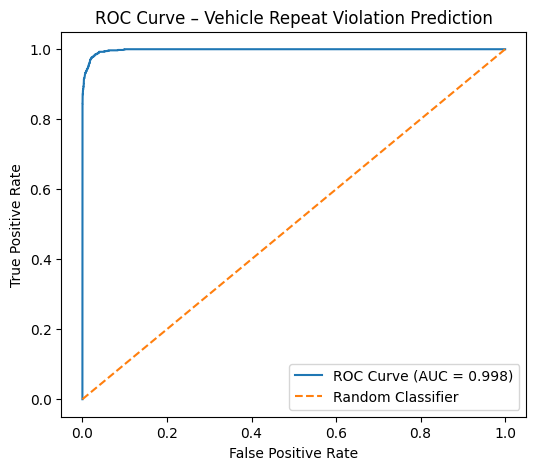

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC value
roc_auc = auc(fpr, tpr)

print("ROC-AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Vehicle Repeat Violation Prediction")
plt.legend()
plt.show()


<Figure size 600x500 with 0 Axes>

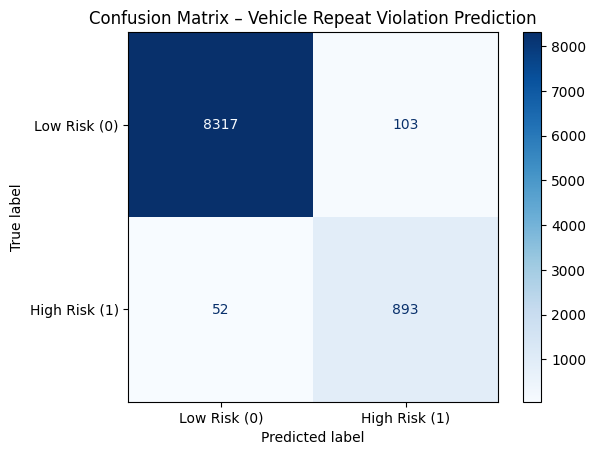

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Risk (0)", "High Risk (1)"]
)

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Vehicle Repeat Violation Prediction")
plt.show()


In [13]:
import joblib
import os

# Ensure model folder exists
model_path = r"C:\Users\HP\Downloads\mini projectnew2\model"
os.makedirs(model_path, exist_ok=True)

# Save the trained model inside model folder
model_file = os.path.join(
    model_path,
    "catboost_vehicle_repeat_violation_model.pkl"
)

joblib.dump(model, model_file)

print("✅ Model saved successfully at:")
print(model_file)


✅ Model saved successfully at:
C:\Users\HP\Downloads\mini projectnew2\model\catboost_vehicle_repeat_violation_model.pkl
